<a href="https://colab.research.google.com/github/gravity102424/ESAA/blob/main/ESAA_OB_week06_2_CNN(1).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 5. 합성곱 신경망1
# 5.1 합성곱 신경망

딥러닝의 역전파는 순전파 과정에 따라 계산된 오차 정보가 신경망의 모든 노드(출력층->은닉층->입력층)로 전송된다. 이러한 계산 과정은 복잡하고 많은 자원(CPU 혹은 GPU, 메모리)를 요구한다. 계산하는 데도 오래 걸린다. 이 문제를 해결하고자 하는 것이 합성곱 신경망이다. 합성곱 신경망은 이미지 전체를 한 번에 계산하는 것이 아닌 이미지의 국소 부분을 계산함으로써 시간과 자원을 절약하여 이미지의 세밀한 부분까지 해석할 수 있는 신경망이다.

## 5.1.1 합성곱층의 필요성

합성곱 신경망은 이미지나 영상을 처리하는 데 유용하다. 예를 들어 다음과 같이 3*3 흑백(그레이스케일) 이미지가 있다고 가정해 보자.

이미지 분석은 다음 그림의 왼쪽과 같은 3*3 배열을 오른쪽과 같이 펼쳐서 각 픽셀에 가중치를 곱하여 은닉층으로 전달하게 된다. 하지만 그림에서 보이는 것처럼 이미지를 펼쳐서 분석하면 데이터의 공간적 구조를 무시하게 되는데, 이것을 방지하려고 도입된 것이 합성곱층이다.

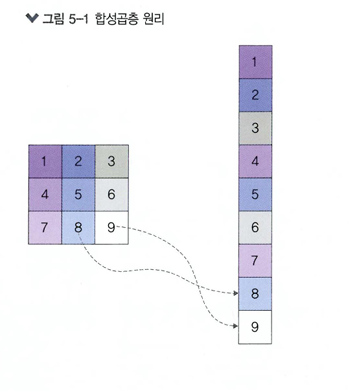

합성곱층의 필요성을 알았으니, 합성곱 신경망을 자세히 살펴보겠다.

## 5.1.2 합성곱 신경망 구조

합성곱 신경망(Convolutional Neural Network, CNN 또는 ConvNet)은 음성 인식이나 이미지/영상 인식에서 주로 사용되는 신경망이다. 다차원 배열 데이터를 처리하도록 구성되어 컬러 이미지 같은 다차원 배열 처리에 특화되어 있으며, 다음과 같이 계층 다섯 개로 구성된다.

1. 입력층
2. 합성곱층
3. 풀링층
4. 완전연결층
5. 출력층

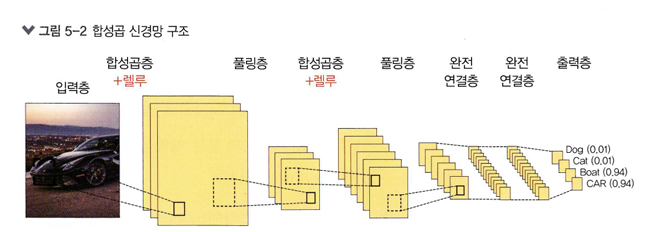

합성곱 신경망은 합성곱층과 풀링층을 거치면서 입력 이미지의 주요 특성 벡터를 추출한다. 그 후 추출된 주요 특성 벡터들은 완전 연결층을 거치면서 1차원 벡터로 변환되며, 마지막으로 출력층에서 활성화 함수인 소프트맥스 함수를 사용하여 최종 결과가 출력된다.

## 입력층

입력층은 입력 이미지 데이터가 최초로 거치게 되는 계층이다. 이미지는 단순 1차원의 데이터가 아닌 높이, 너비, 채널의 값을 갖는 3차원 데이터이다. 이때 채널은 이미지가 그레이스케일(gray scale)이면 1값을 가지며, 컬러(RGB)이면 3값을 갖는다.
예를 들어 다음 그림과 같은 형태는 높이 4, 너비 4, 채널은 RGB를 갖고 있으므로, 이미지 형태(shape)는 (4,4,3)으로 표현할 수 있다.

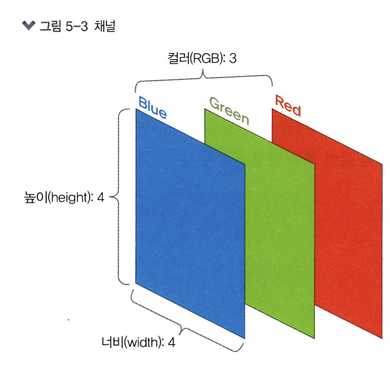

## 합성곱층
합성곱층(convolutional layer)은 입력 데이터에서 특성을 추출하는 역할을 수행한다.
특성 추출은 일단 이미지가 들어왔을 때 이미지에 대한 특성을 감지하기 위해 커널이나 필터를 사용한다. 커널/필터는 이미지의 모든 영역을 훑으면서 특성을 추출하게 되는데, 이렇게 추출된 결과물이 특성 맵(feature map)이다.

이때 커널은 3*3, 5*5 크기로 적용되는 것이 일반적이며, 스트라이드라는 지정된 간격에 따라 순차적으로 이동한다.

다음은 스트라이드가 1일 때 이동하는 과정이다.

## 1단계. 입력 이미지에 3*3 필터 적용
입력 이미지와 필터를 포개 놓고 대응되는 숫자끼리 곱한 후 모두 더한다.

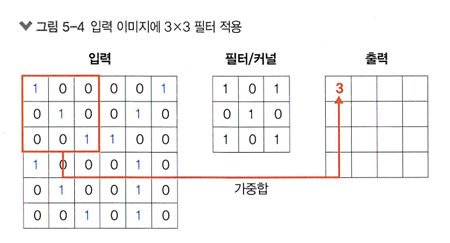


## 2단계. 필터가 1만큼 이동

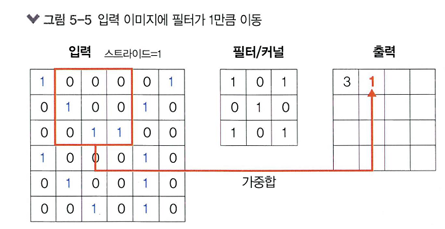

## 3단계. 필터가 1만큼 두 번째 이동

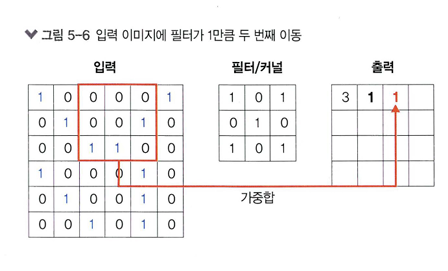

## 4단계. 필터가 1만큼 세 번째 이동
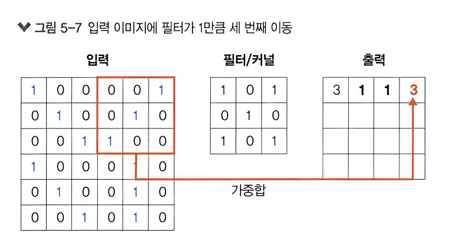

## 5단계. 필터가 1만큼 네 번째 이동
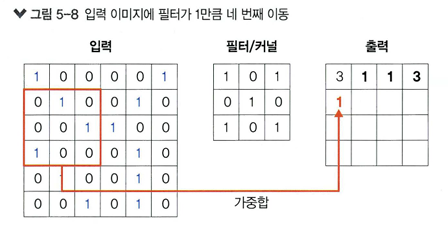

## 6단계. 필터가 1만큼 마지막으로 이동

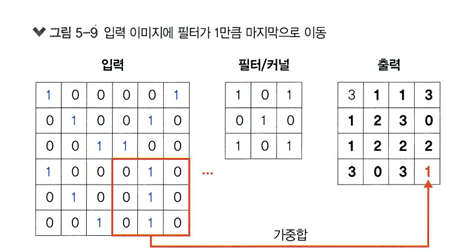

앞의 그림에서는 이미지 크기가 (6,6,1)이며, 3*3 크기의 커널/필터가 스트라이드 1 간격으로 이동하면서 합성곱 연산을 수행하는 것을 보여 준다. 이렇게 커널은 스트라이드 간격만큼 순회하면서 모든 입력 값과의 합성곱 연산으로 새로운 특성 맵을 만들게 되며, 앞의 그림과 같이 커널과 스트라이드의 상호 작용으로 원본 (6,6,1) 크기가 (4,4,1) 크기의 특성 맵으로 줄어들었다.

지금까지 그레이스케일에 대한 이미지를 확인했는데, 이제 컬러 이미지의 합성곱을 알아보겠다.

앞서 다룬 그레이스케일 이미지와 구분되는 특징은 첫째, 필터 채널이 3이라는 것과 둘째, RGB 각각에 서로 다른 가중치로 합성곱을 적용한 후 결과를 더해 준다는 것이다. 그 외 스트라이드 및 연산하는 방법은 동일하다. 이때 필터 채널이 3이라고 해서 필터 개수도 세 개라고 오해하기 쉬운데, 실제로는 필터 개수가 한 개라는 점에 주의해야 한다.
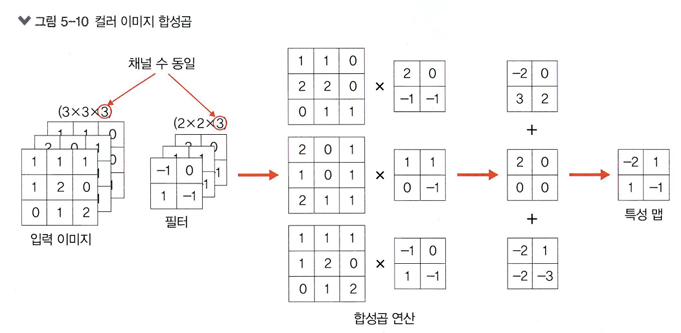


그렇다면 필터가 두 개 이상인 합성곱은 어떤 형태일까? 필터가 두 개 이상이면 그림 5-11과 같이 필터 각각은 특성 추출 결과의 채널이 된다.

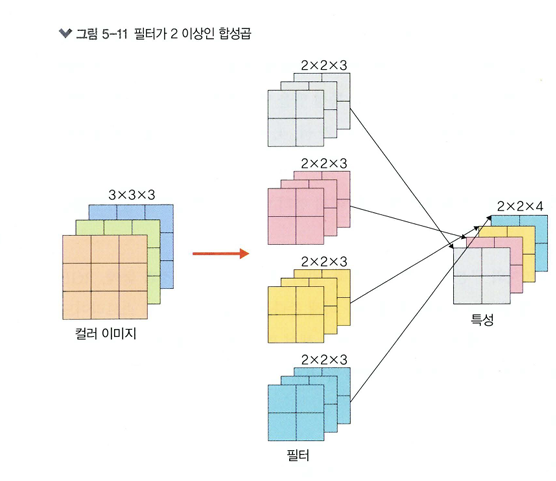

즉, 합성곱층을 요약하면 다음과 같다.

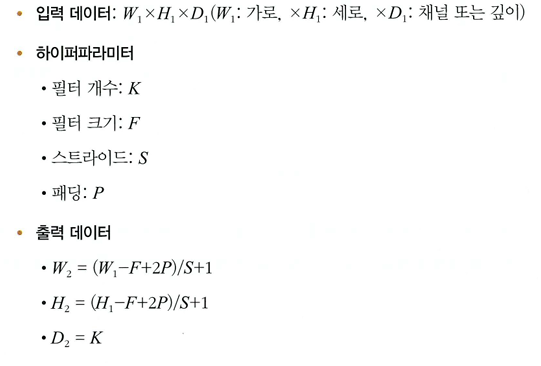

## 풀링층

풀링층(pooling layer)은 합성곱층과 유사하게 특성 맵의 차원을 다운 샘플링하여 연산량을 감소시키고, 주요한 특성 벡터를 추출하여 학습을 효과적으로 할 수 있게 한다.

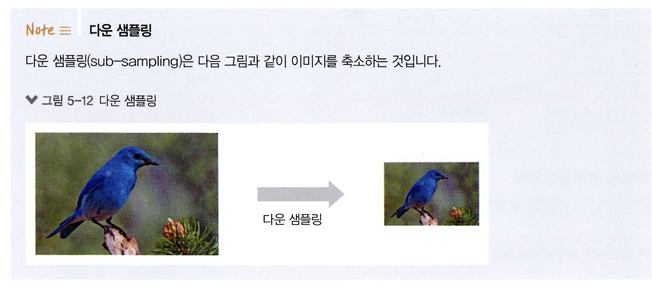

풀링 연산에는 두 가지가 사용된다.
* 최대 풀링(max pooling): 대상 영역에서 최댓값을 추출
* 평균 풀링(average pooling): 대상 영역에서 평균을 반환


하지만 대부분의 합성곱 신경망에서는 최대 풀링이 사용되는데, 평균 풀링은 각 커널 값을 평균화시켜 중요한 가중치를 갖는 값의 특성이 희미해질 수 있기 때문이다.

다음은 최대 풀링의 연산 과정이다.

## 첫 번째 최대 풀링 과정
3,-1,-3,1 값 중에서 최댓값(3)을 선택한다.
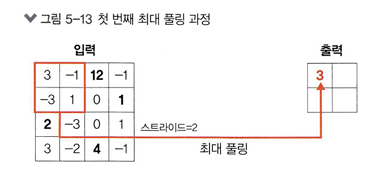

## 두 번째 최대 풀링 과정
12,-1,0,1 값 중에서 최댓값(12)을 선택한다.

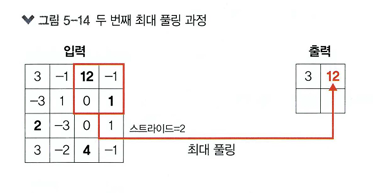

## 세 번째 최대 풀링 과정
2,-3,3,-2 값 중에서 최댓값(3)을 선택한다.
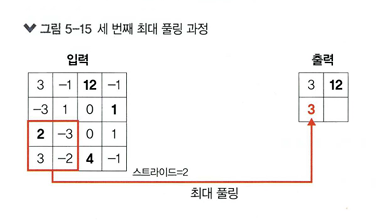

## 네 번째 최대 풀링 과정

0,1,4,-1 값 중에서 최댓값(4)을 선택한다.

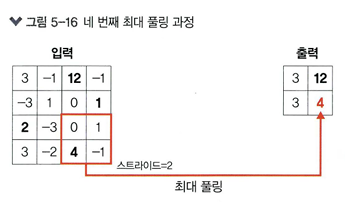


평균 풀링의 계산 과정은 최대 풀링과 유사한 방식으로 진행하되 다음과 같이 각 필터의 평균으로 계산한다.

0 = (3+(-1)+(-3)+1)/4
3 = (12+(-1)+0+1)/4
0 = (2+(-3)+3+(-2))/4
1 = (0+1+4+(-1))/4

다음 그림은 최대 풀링과 평균 풀링 결과를 비교한 것이다.

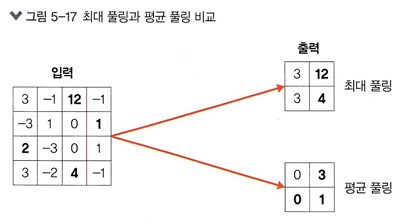

최대 풀링과 평균 풀링을 요약한면 다음과 같다.

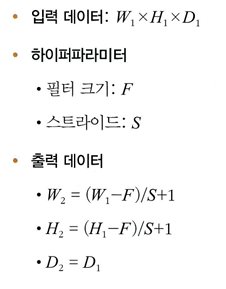


## 완전연결층

합성곱층과 풀링층을 거치면서 차원이 축소된 특성 맵은 최종적으로 완전연결층(fully connected layer)으로 전달된다. 이 과정에서 이미지는 3차원 벡터에서 1차원 벡터로 펼쳐지게(flatten) 된다.

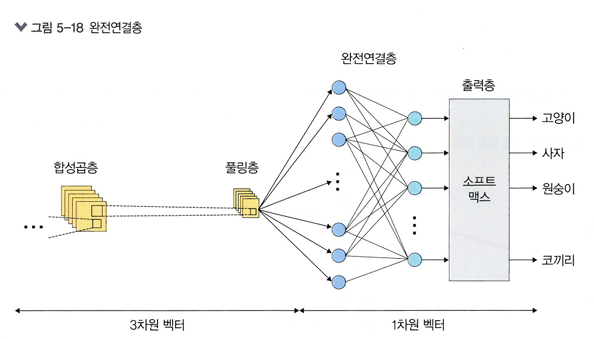

## 출력층
출력층(output layer)에서는 소프트맥스 활성화 함수가 사용되는데, 입력받은 값을 0~1 사이의 값으로 출력한다. 따라서 마지막 출력층의 소프트맥스 함수를 사용하여 이미지가 각 레이블에 속할 확률 값이 출력되며, 이때 가장 높은 확률 값을 갖는 레이블이 최종 값으로 선정된다.



## 5.1.3 1D, 2D, 3D 합성곱

합성곱은 이동하는 방향의 수와 출력 형태에 따라 1D, 2D, 3D로 분류할 수 있다.

## 1D 합성곱

1D 합성곱은 필터가 시간을 축으로 좌우로만 이동할 수 있는 합성곱이다. 따라서 입력(W)과 필터(k)에 대한 출력은 W가 된다. 예를 들어 입력이 [1,1,1,1,1]이고 필터가 [0.25, 0.5, 0.25]라면, 출력은 [1,1,1]이 된다. 즉, 다음 그림과 같이 출력 형태는 1D의 배열이 되며, 그래프 곡선을 완화할 때 많이 사용된다.

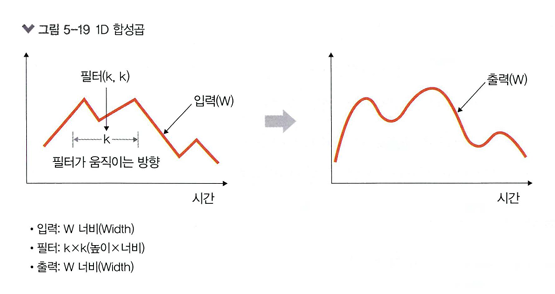

## 2D 합성곱

2D 합성곱은 필터가 다음 그림과 같이 방향 두 개로 움직이는 형태이다. 즉, 입력(W, H)과 필터(k,k)에 대한 출력은 (W,H)가 되며, 출력 형태는 2D 행렬이 된다.

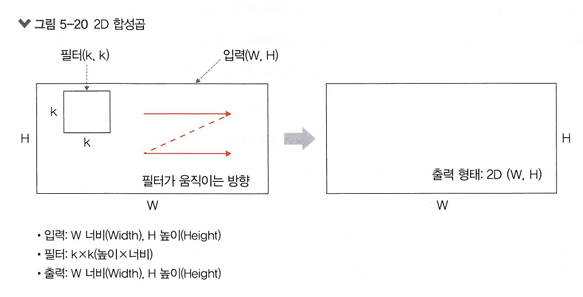

## 3D 합성곱

3D 합성곱은 필터가 움직이는 방향이 그림 5-21과 같이 세 개가 있다. 입력(W, H, L)에 대해 필터(k,k,d)를 적용하면 출력으로 (W, H, L)을 갖는 형태가 3D 합성곱이다. 출력은 3D 형태이며, 이때 d<L을 유지하는 것이 중요하다.

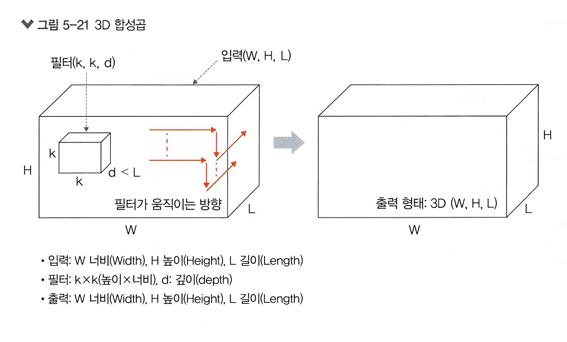

## 3D 입력을 갖는 2D 합성곱

입력이 (224 x 224 x3, 112 X 112 X 32)와 같은 3D 형태임에도 출력 형태가 3D가 아닌 2D 행렬을 취하는 것이 '3D 입력을 갖는 2D 합성곱'이다. 이것은 필터에 대한 길이(L)가 입력 채널의 길이(L)와 같아야하기 때문에 이와 같은 합성곱 형태가 만들어진다. 즉， 입력(W, H, L)에 필터
(k, k, L)를 적용하면 출력은 (W, H)가 된다. 이때 필터는 다음 그림과 같이 두 방향으로 움직이며 출력 형태는 2D 행렬이 된다.

3D 입력을 갖는 2D 합성곱의 대표적 사례로는 LeNet-5와 VGG가 있다.
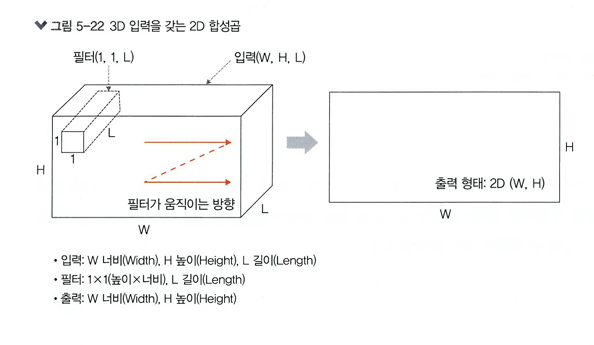

## 1x1 합성곱
1x1 합성곱은 3D 형태로 입력된다. 즉, 입력(W, H, L)에 필터(1,1,L)를 적용하면 출력은 (W,H)가 된다. 1x1 합성곱에서 채널 수를 조정해서 연산량이 감소되는 효과가 있으며, 대표적 사례로는 GoogLeNet이 있다.

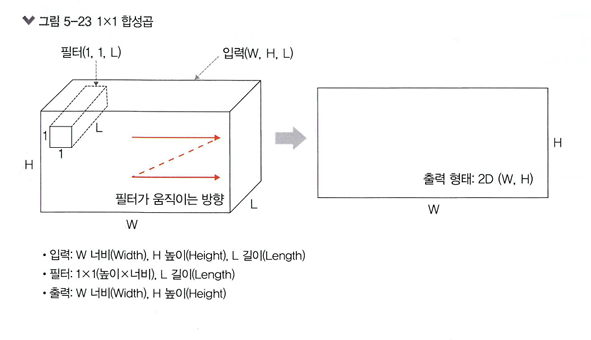
